In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('data/job_salary_prediction_dataset.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 250000 rows, 10 columns


In [3]:
# Preview the data
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
# Display all column names
print("Column names:")
print(df.columns.tolist())

Column names:
['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']


In [5]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
# Count missing values per column
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [7]:
# Summary statistics
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [10]:
# Drop rows with missing salary
df = df.dropna(subset=['salary'])

# Fill other missing values with mode for object columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Data cleaned. New shape: {df.shape}")

Data cleaned. New shape: (250000, 10)


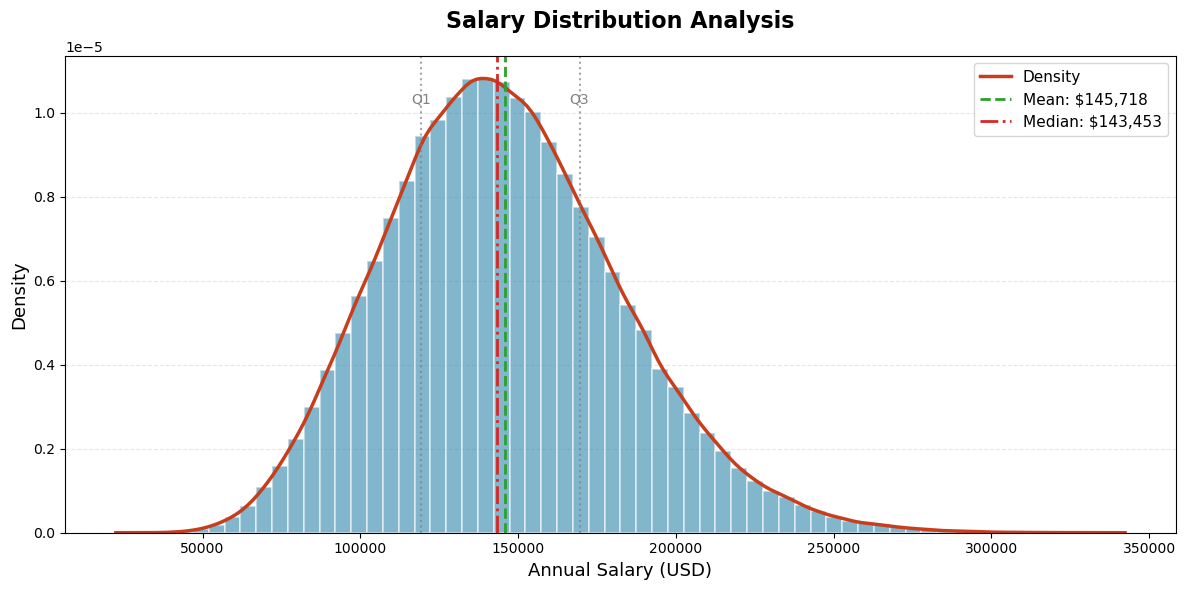

In [12]:
#薪资分布直方图
fig, ax = plt.subplots(figsize=(12, 6))

# Create histogram with KDE
n, bins, patches = ax.hist(df['salary'], bins=60, alpha=0.6, 
                            color='#2E86AB', edgecolor='white', linewidth=1.2, density=True)
sns.kdeplot(df['salary'], ax=ax, color='#C73E1D', linewidth=2.5, label='Density')

# Add mean and median lines
mean_salary = df['salary'].mean()
median_salary = df['salary'].median()
ax.axvline(mean_salary, color='#2ca02c', linestyle='--', linewidth=2, label=f'Mean: ${mean_salary:,.0f}')
ax.axvline(median_salary, color='#d62728', linestyle='-.', linewidth=2, label=f'Median: ${median_salary:,.0f}')

# Add quartile annotations
q1 = df['salary'].quantile(0.25)
q3 = df['salary'].quantile(0.75)
ax.axvline(q1, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(q3, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(q1, ax.get_ylim()[1]*0.9, 'Q1', ha='center', fontsize=10, color='gray')
ax.text(q3, ax.get_ylim()[1]*0.9, 'Q3', ha='center', fontsize=10, color='gray')

ax.set_title('Salary Distribution Analysis', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Annual Salary (USD)', fontsize=13, fontweight='medium')
ax.set_ylabel('Density', fontsize=13, fontweight='medium')
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [14]:
# Average salary by education level
edu_salary = df.groupby('education_level')['salary'].mean().sort_values(ascending=False)

print("edu_salary created:")
print(edu_salary)

edu_salary created:
education_level
PhD            163976.005295
Master         153305.307833
Bachelor       142410.531291
Diploma        137158.574976
High School    131715.336243
Name: salary, dtype: float64


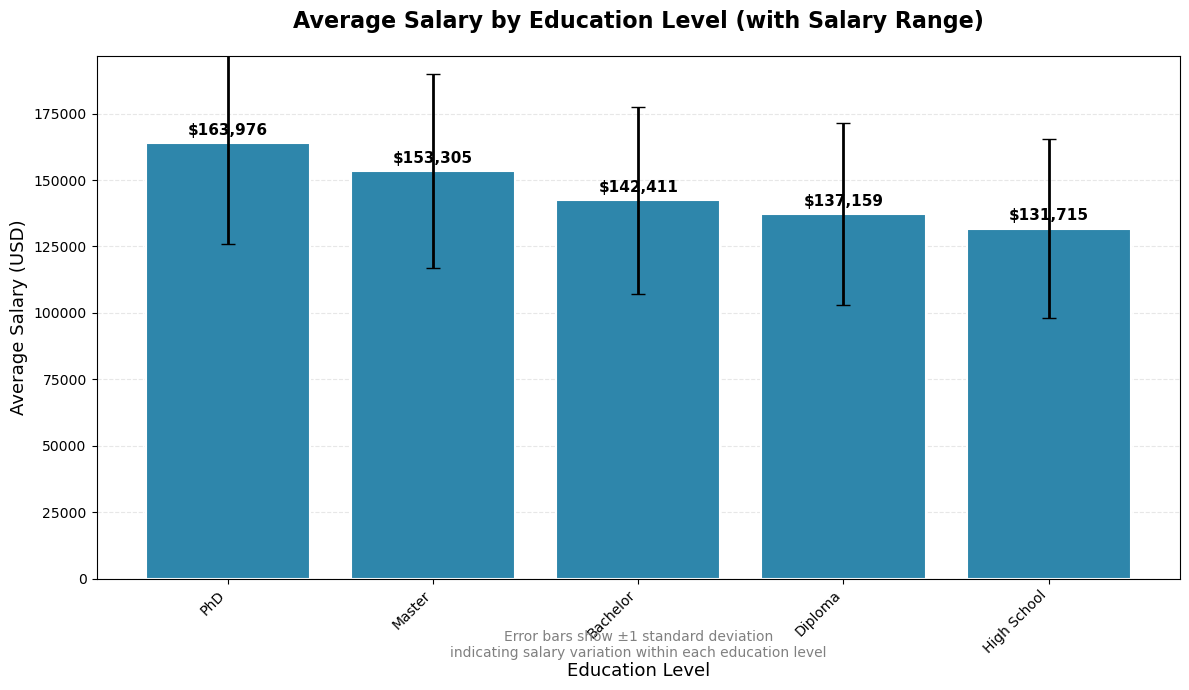

In [17]:
#教育水平薪资
# Calculate mean and std for each education level
edu_stats = df.groupby('education_level')['salary'].agg(['mean', 'std']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

# Create bars
bars = ax.bar(edu_stats.index, edu_stats['mean'], 
              color='#2E86AB', edgecolor='white', linewidth=1.5,
              yerr=edu_stats['std'], capsize=5, error_kw={'linewidth': 2, 'color': '#C73E1D'})

# Add value labels
for bar, mean_val in zip(bars, edu_stats['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2000,
            f'${mean_val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Average Salary by Education Level (with Salary Range)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Education Level', fontsize=13, fontweight='medium')
ax.set_ylabel('Average Salary (USD)', fontsize=13, fontweight='medium')
ax.set_ylim(0, edu_stats['mean'].max() * 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add annotation explaining error bars
ax.annotate('Error bars show ±1 standard deviation\nindicating salary variation within each education level',
            xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=10, color='gray')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

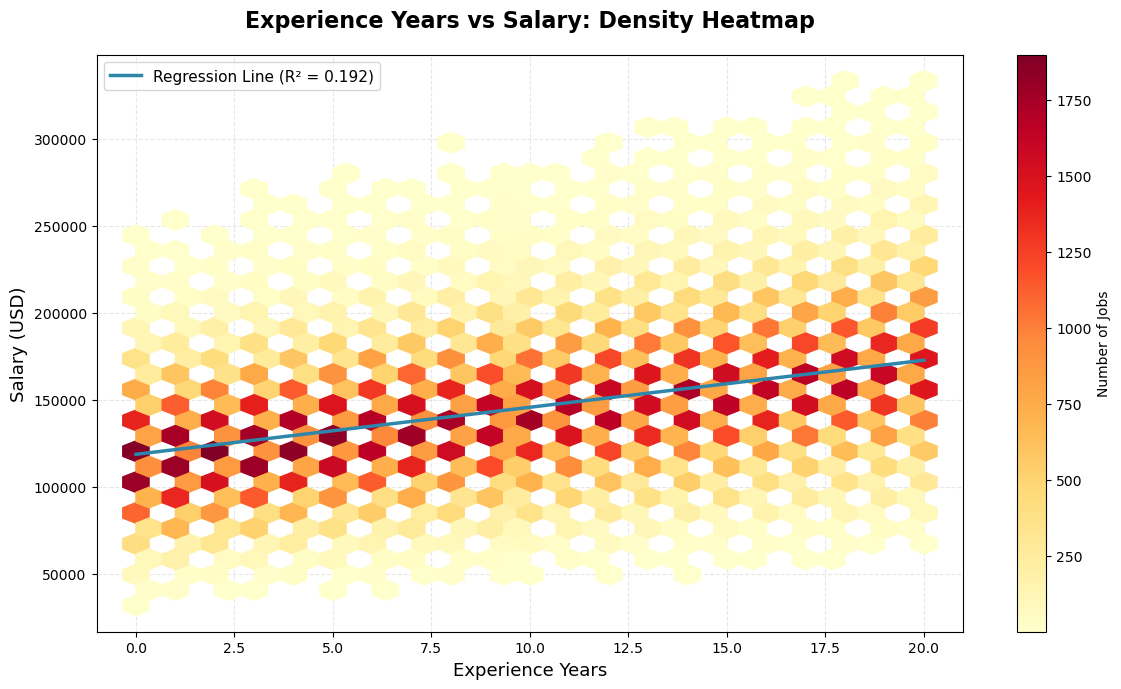

In [18]:
#经验年限vs薪资
fig, ax = plt.subplots(figsize=(12, 7))

# Hexbin plot shows density of points
hb = ax.hexbin(df['experience_years'], df['salary'], gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax, label='Number of Jobs')

# Add regression line
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(df['experience_years'], df['salary'])
x_line = np.array([df['experience_years'].min(), df['experience_years'].max()])
ax.plot(x_line, intercept + slope * x_line, color='#2E86AB', linewidth=2.5, 
        label=f'Regression Line (R² = {r_value**2:.3f})')

ax.set_title('Experience Years vs Salary: Density Heatmap', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Experience Years', fontsize=13, fontweight='medium')
ax.set_ylabel('Salary (USD)', fontsize=13, fontweight='medium')
ax.legend(loc='upper left', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

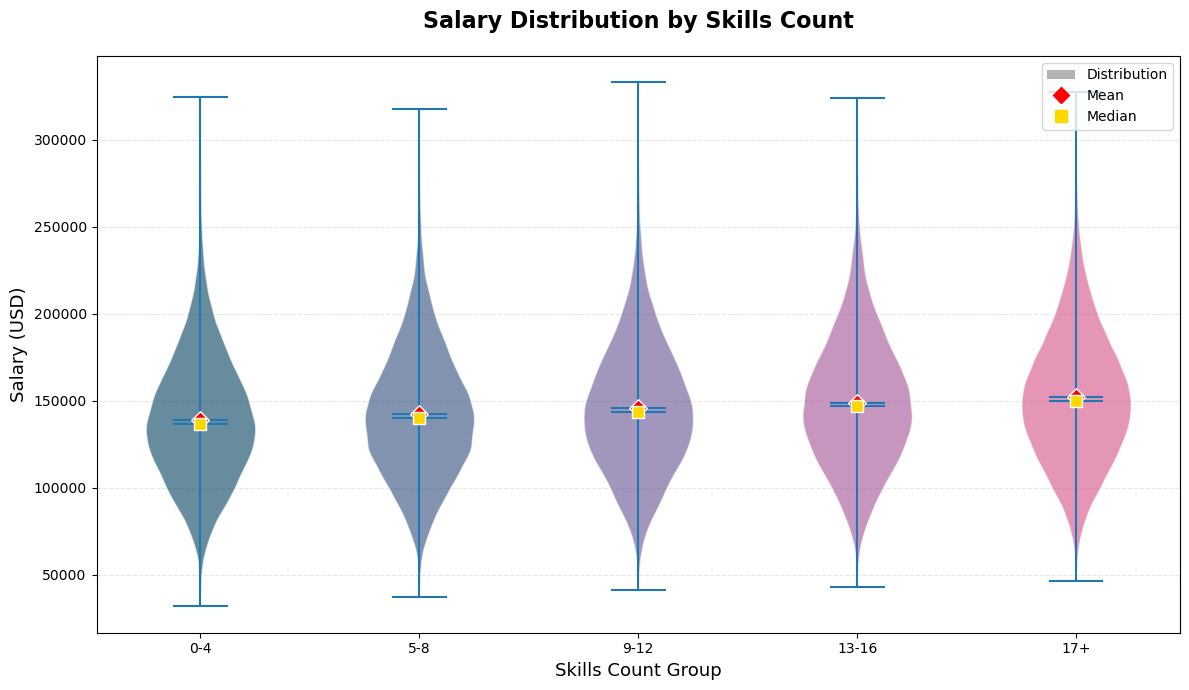

In [19]:
#技能数量vs薪资
# Create skill level groups for better visualization
df['skill_group'] = pd.cut(df['skills_count'], bins=5, labels=['0-4', '5-8', '9-12', '13-16', '17+'])

fig, ax = plt.subplots(figsize=(12, 7))

# Create violin plot by skill group
order = ['0-4', '5-8', '9-12', '13-16', '17+']
parts = ax.violinplot([df[df['skill_group'] == g]['salary'].values for g in order],
                       positions=range(len(order)), showmeans=True, showmedians=True)

# Customize violins
colors_violin = ['#003f5c', '#2f4b7c', '#665191', '#a05195', '#d45087']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_violin[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('white')
    pc.set_linewidth(1)

# Add mean and median markers
for i, g in enumerate(order):
    mean_val = df[df['skill_group'] == g]['salary'].mean()
    median_val = df[df['skill_group'] == g]['salary'].median()
    ax.scatter(i, mean_val, marker='D', s=80, color='red', edgecolor='white', zorder=10)
    ax.scatter(i, median_val, marker='s', s=80, color='gold', edgecolor='white', zorder=10)

ax.set_title('Salary Distribution by Skills Count', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Skills Count Group', fontsize=13, fontweight='medium')
ax.set_ylabel('Salary (USD)', fontsize=13, fontweight='medium')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gray', alpha=0.6, label='Distribution'),
                   plt.Line2D([0], [0], marker='D', color='red', markerfacecolor='red', 
                              markersize=8, label='Mean', linestyle='None'),
                   plt.Line2D([0], [0], marker='s', color='gold', markerfacecolor='gold', 
                              markersize=8, label='Median', linestyle='None')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

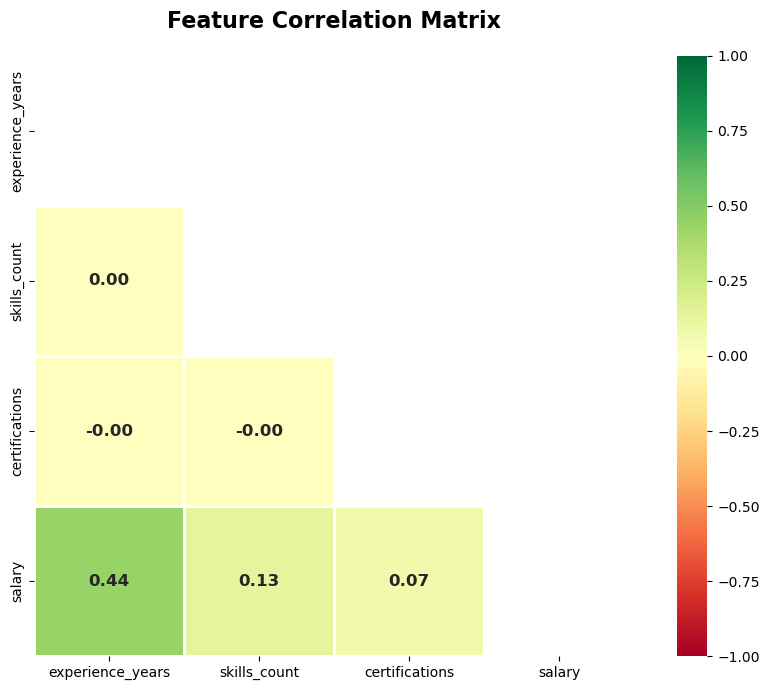

In [20]:
#相关性热力图
# Select numerical columns
numeric_cols = ['experience_years', 'skills_count', 'certifications', 'salary']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

# Create masked array for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap with mask
im = sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlGn', 
                 vmin=-1, vmax=1, center=0, fmt='.2f',
                 square=True, linewidths=1, linecolor='white',
                 annot_kws={'size': 12, 'fontweight': 'bold'})

ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

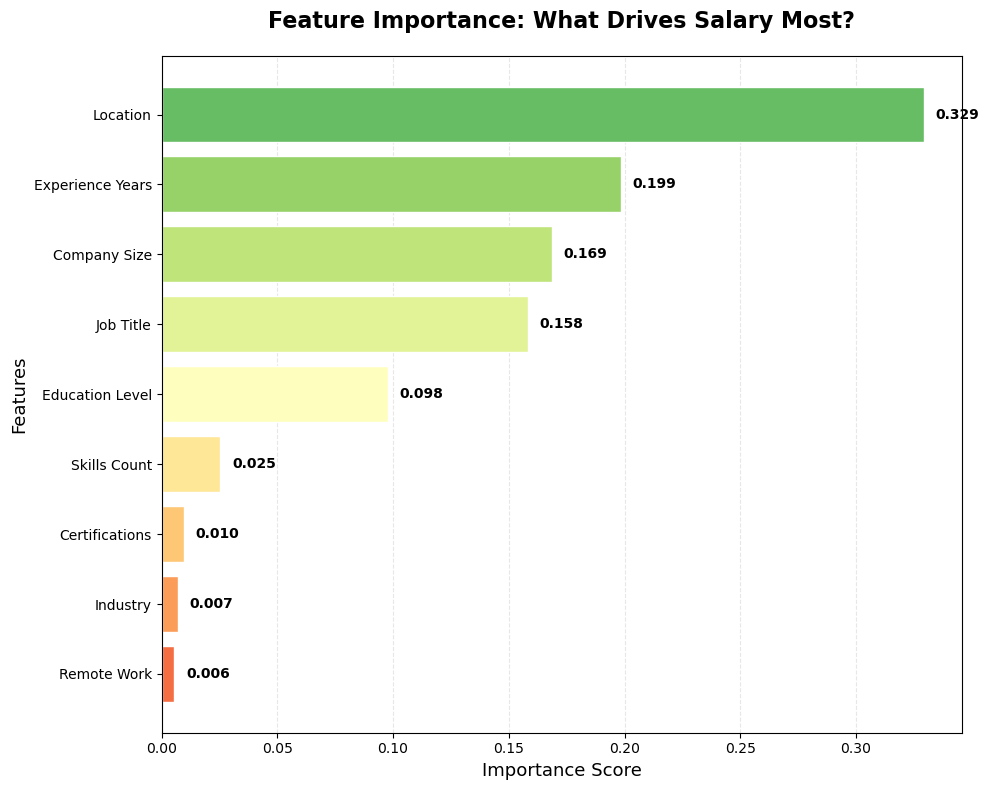

In [41]:
# Plot feature importance
importances = model.feature_importances_
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 8))

# Create horizontal bar chart
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(indices)))
bars = ax.barh(range(len(indices)), importances[indices], color=colors_imp, edgecolor='white', linewidth=1)

# Add value labels
for i, (bar, idx) in enumerate(zip(bars, indices)):
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
            f'{importances[idx]:.3f}', ha='left', va='center', fontsize=10, fontweight='bold')

# Clean up feature names
feature_names_clean = [feature_cols[idx].replace('_encoded', '').replace('_', ' ').title() for idx in indices]
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(feature_names_clean)

ax.set_title('Feature Importance: What Drives Salary Most?', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Importance Score', fontsize=13, fontweight='medium')
ax.set_ylabel('Features', fontsize=13, fontweight='medium')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

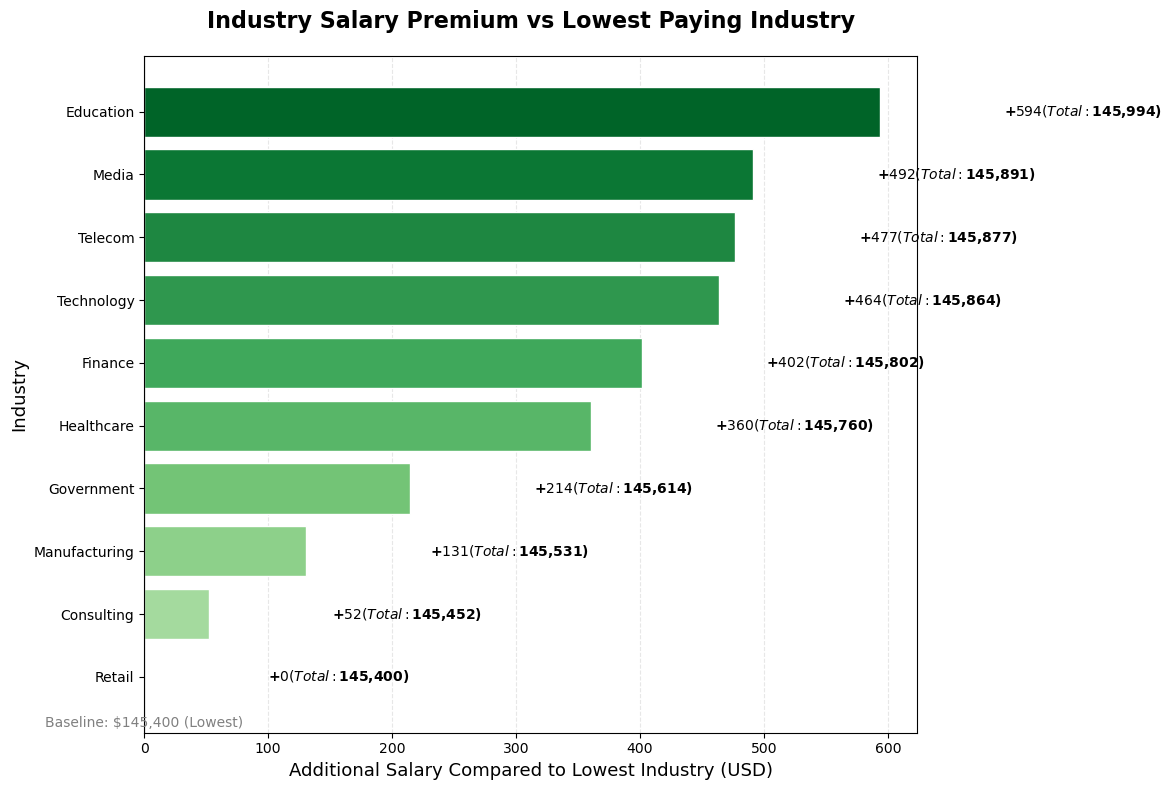

In [45]:
#按行业看薪资
# Calculate average salary by industry
industry_avg = df.groupby('industry')['salary'].mean().sort_values()

# Calculate difference from lowest
min_salary = industry_avg.min()
industry_diff = industry_avg - min_salary

fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart for differences
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(industry_diff)))
bars = ax.barh(industry_diff.index, industry_diff.values, color=colors, edgecolor='white', linewidth=1)

# Add labels showing both difference and total salary
for bar, total_salary, diff in zip(bars, industry_avg.values, industry_diff.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'+${diff:,.0f}  (Total: ${total_salary:,.0f})', 
            ha='left', va='center', fontsize=10, fontweight='bold')

# Add baseline annotation
ax.axvline(x=0, color='gray', linewidth=1, linestyle='-', alpha=0.5)
ax.text(0, -0.8, f'Baseline: ${min_salary:,.0f} (Lowest)', ha='center', fontsize=10, color='gray')

ax.set_title('Industry Salary Premium vs Lowest Paying Industry', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Additional Salary Compared to Lowest Industry (USD)', fontsize=13, fontweight='medium')
ax.set_ylabel('Industry', fontsize=13, fontweight='medium')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [46]:
# Save model and encoders
joblib.dump(model, 'model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("Model and encoders saved successfully!")

Model and encoders saved successfully!
